# 04. Generalizace rozhodovacího stromu (*Decision Tree*)

## Cvičení:

1. Otestujte, zda je zadaný problém lineárně separovatelný, porovnejte logistickou regresi a rozhodovací stromy. 

2. Vyhodnoťte, kdy se rozhodovací strom začne přeučovat s ohledem na hloubku stromu. 

3. Vylaďte hyperparametry DT pomocí techniky křížové validace (cross-validation grid search); uveďte nejlepší hyperparametry a dosaženou přesnost.

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV 

import matplotlib.pyplot as plt
np.random.seed(0)

/home/lukas/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Data

In [2]:
X, y = make_classification(n_samples=10000, n_features=20,
                           n_informative=5, n_redundant=15, random_state=1)

In [3]:
X.shape

(10000, 20)

In [4]:
y.shape

(10000,)

In [5]:
# Třídy
np.unique(y)

array([0, 1])

In [6]:
# Rozdělte data na trénovací a testovací (50%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [7]:
X_train.shape

(5000, 20)

### 1. Je problém lineárně separabilní?
Model: logistická regrese

In [8]:
# LR model
lr_model = LogisticRegression(random_state=0)

In [9]:
# fitování
lr_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following as

In [10]:
y_train_pred = lr_model.predict(X_train) 
# y_train_pred.shape

(5000,)

In [14]:
# trénovací přesnost 
OA_train = accuracy_score(y_train, y_train_pred)
print(f'Celkova presnost uceni Log reg.: {round(OA_train * 100, 1)} %')

Celkova presnost uceni Log reg.: 85.4 %


In [15]:
# testovací přesnost 
y_test_pred = lr_model.predict(X_test) 
OA_test = accuracy_score(y_test, y_test_pred)
print(f'Celkova presnost testovani Log reg.: {round(OA_test * 100, 1)} %')

Celkova presnost testovani Log reg.: 86.5 %


### Rozhodovací strom (*Decision Tree Classifier*)

In [16]:
# DT model
dt_model = DecisionTreeClassifier(random_state=0)

In [17]:
# fitování  
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples 

In [18]:
# trénovací přesnost
y_train_pred_dt = dt_model.predict(X_train) 
OA_train_dt = accuracy_score(y_train, y_train_pred_dt)
print(f'Celkova presnost uceni DT: {round(OA_train_dt * 100, 1)} %')

Celkova presnost uceni DT: 100.0 %


In [19]:
# testovací přesnost
y_test_pred_dt = dt_model.predict(X_test) 
y_test_pred_dt = dt_model.predict(X_test) 
OA_test_dt = accuracy_score(y_test, y_test_pred_dt)
print(f'Celkova presnost testovani DT: {round(OA_test_dt * 100, 1)} %')

Celkova presnost testovani DT: 90.9 %


### 2. Kdy se model DT() začne nadměrně přeučovat?

In [22]:
# oveřte DT model v cyklu pro hloubku stromu od 1 do 20 
# uložte trénovací a testovací přesnost pro každou hloubku 
train_accuracy = []
test_accuracy = []

for depth in range(1, 21, 1): 
    # print(depth) 
    dt_model = DecisionTreeClassifier(random_state=0, max_depth = depth) 
    dt_model.fit(X_train, y_train)
    # trénovací přesnost
    y_train_pred_dt = dt_model.predict(X_train) 
    OA_train_dt = accuracy_score(y_train, y_train_pred_dt)

    # testovací přesnost
    y_test_pred_dt = dt_model.predict(X_test) 
    y_test_pred_dt = dt_model.predict(X_test) 
    OA_test_dt = accuracy_score(y_test, y_test_pred_dt)
    
    print(f'Celkova presnost uceni DT(depth: {depth}) {round(OA_train_dt * 100, 1)}  a testovani: {round(OA_test_dt * 100, 1)} %')
    train_accuracy.append(OA_train_dt)
    test_accuracy.append(OA_test_dt)

Celkova presnost uceni DT(depth: 1) 76.9  a testovani: 76.4 %
Celkova presnost uceni DT(depth: 2) 80.4  a testovani: 80.9 %
Celkova presnost uceni DT(depth: 3) 88.1  a testovani: 87.9 %
Celkova presnost uceni DT(depth: 4) 90.1  a testovani: 89.6 %
Celkova presnost uceni DT(depth: 5) 91.2  a testovani: 90.3 %
Celkova presnost uceni DT(depth: 6) 93.2  a testovani: 91.4 %
Celkova presnost uceni DT(depth: 7) 94.0  a testovani: 91.7 %
Celkova presnost uceni DT(depth: 8) 94.9  a testovani: 91.7 %
Celkova presnost uceni DT(depth: 9) 95.7  a testovani: 92.0 %
Celkova presnost uceni DT(depth: 10) 96.7  a testovani: 91.6 %
Celkova presnost uceni DT(depth: 11) 97.5  a testovani: 91.4 %
Celkova presnost uceni DT(depth: 12) 98.3  a testovani: 91.7 %
Celkova presnost uceni DT(depth: 13) 98.7  a testovani: 91.9 %
Celkova presnost uceni DT(depth: 14) 98.9  a testovani: 91.0 %
Celkova presnost uceni DT(depth: 15) 99.2  a testovani: 91.3 %
Celkova presnost uceni DT(depth: 16) 99.4  a testovani: 91.3 %
C

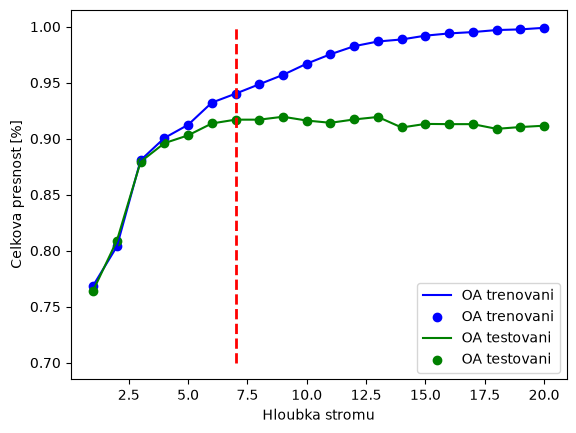

In [38]:
# Vykreslsste závislost přesnosti trénování a testování modelu na hloubce modelu.
# Určete vizuálně hloubku modelu kdy začíná přeučování 
plt.plot(list(range(1, 21, 1)), train_accuracy, label = 'OA trenovani', color = 'blue')
plt.scatter(list(range(1, 21, 1)), train_accuracy, label = 'OA trenovani', color = 'blue')
plt.plot(list(range(1, 21, 1)), test_accuracy, label = 'OA testovani', color = 'green')
plt.scatter(list(range(1, 21, 1)), test_accuracy, label = 'OA testovani', color = 'green')
plt.vlines(x=7, ymin=0.7, ymax=1, color='red', linestyle='--', linewidth=2)
plt.xlabel('Hloubka stromu')
plt.ylabel('Celkova presnost [%]')
plt.legend()

In [42]:
(train_accuracy[6] - test_accuracy[6]) * 100 

2.32

### 3. Vylďte DT model pomocí křížové validace a vyhledávání v gridu hyperparametrů

In [ ]:
# https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
pass 

In [45]:
# Křížové validace a vyhledávání v gridu hyperparametrů
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

hyperparameter_space = {'max_depth': [2,4,6,8,10,15],
                        'min_samples_leaf': [1,2,3]}
# hyperparameter_space

dtc = DecisionTreeClassifier()
gs = GridSearchCV(dtc, param_grid = hyperparameter_space, n_jobs=6,
                  scoring="accuracy", cv = 5, return_train_score=True)

In [46]:
gs

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 4, ...], 'min_samples_leaf': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",6
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.S

In [47]:
# fitování gs modelu
gs.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 4, ...], 'min_samples_leaf': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",6
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.S

In [49]:
# Optimální parametry a skóre
print("Optimální parametry a skóre: ", gs.best_params_)
print("Průměrná křížově ověřená přesnost (%): ", round(gs.best_score_ * 100, 2))

Optimální parametry a skóre:  {'max_depth': 10, 'min_samples_leaf': 3}
Průměrná křížově ověřená přesnost (%):  91.6


In [ ]:
# Testovací přesnost accuracy
pass 